# Magnificent-Seven — a quantitative teardown 🔬
### HAC t-stat of the basket spread · equal-weight-field decomposition · the ex-post-selection placebo · the random-basket distribution · a no-edge synthetic null

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Repeatable_strategy%3F: Busted](https://img.shields.io/badge/Repeatable_strategy%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two claims the Mag-7 label fuses: a **real** realised spread over the S&P 500 (HAC *t* = 3.4 on the monthly difference) from an **absent** forward edge (the basket is selected on the outcome). The decisive object is the **ex-post-selection placebo**: "pick the *k* highest-realised-return names" — which manufactures a large spread even on a tape where *no* name has any true edge.

> ⚠️ **Not investment advice.** Real data: yfinance monthly total returns, a 40-name mega-cap field + SPY, 130 months to 2026-05. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magnificent_seven import data, strategy as st

# Real tape is cache-first and never hits the network here; absent cache -> quote frozen R.
try:
    RETS, BENCH = data.load_real(allow_lookahead_selection=True)
    HAVE_REAL = True
except (FileNotFoundError, Exception):
    RETS, BENCH, HAVE_REAL = None, None, False
print("real monthly panel cache present:", HAVE_REAL,
      "| months:", (0 if RETS is None else len(RETS)),
      "| names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2015-08 → 2026-05', 'months': 130, 'n_universe': 40, 'fp': '52a10ec50b92', 'mag7_cagr': 36.24, 'mag7_sharpe': 1.33, 'mag7_dd': -45.7, 'spy_cagr': 14.41, 'spy_sharpe': 0.96, 'spy_dd': -23.9, 'eqf_cagr': 18.97, 'eqf_sharpe': 1.16, 'eqf_dd': -27.0, 'expost_cagr': 44.25, 'expost_sharpe': 1.42, 'mag7_net_cagr': 36.15, 't_bench': 3.41, 'spread_bench_ann': 19.9, 't_equal': 2.88, 'spread_equal_ann': 15.8, 'mag7_spread': 21.83, 'expost_spread': 29.84, 'selection_share': 137, 'expost_members': ['NVDA', 'AMD', 'TSLA', 'GOOGL', 'AAPL', 'MSFT', 'AMZN'], 'mag7_pctile': 99.7, 'rand_mean': 4.06, 'rand_median': 3.08, 'syn_null_named': -2.13, 'syn_null_named_t': -1.15, 'syn_null_placebo': 10.67, 'syn_edge_named': 1.98, 'syn_edge_named_t': 1.2, 'syn_edge_placebo': 11.16}


real monthly panel cache present: True | months: 130 | names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Mag 7 − SPY = **+19.9%/yr**, HAC **t = 3.41** (n = 130); **t = 2.88** even vs the equal-weight field. *But* the basket is selected on the outcome — the synthetic null manufactures a spread with **zero** true edge, so the forward case is `WEAK`. |
| **Tradability** | `MIRAGE` | You could not have named these seven in 2015. A *blind* 7-pick beat SPY by **~4.1%/yr** (Mag 7 at the **99.7th** percentile of 2,000 draws); the ex-post rule reproduces **137%** of the spread. Costs are trivial — the mirage is selection. |
| **Repeatable strategy?** | `BUSTED` | "Hold the realised winners" is a label, not a rule. Forward, you get the random distribution (median +3%/yr, a −46% drawdown), not +22%. |

> 💡 In plain words: the seven genuinely out-earned — and the tape is what *named* them. Strip the hindsight and the forward-pickable edge is ~4%, not ~22%.

## 1 · The claim, steelmanned

Let the field be $N$ mega-caps with monthly total returns $r_{it}$. The Mag-7 basket is an equal-weight hold of a *fixed* set $S^\star$ of $|S^\star|=7$ names; the benchmark is the S&P 500 (SPY), $b_t$.

- **H₁ (the spread is real).** $\mathbb{E}[r^{S^\star}_t - b_t] > 0$ on the tape, with a robust HAC *t*.
- **H₂ (it is a forward factor).** $S^\star$ is identifiable *ex ante* — the spread survives being chosen **without** look-ahead.
- **H₃ (it is repeatable).** A forward rule reproduces the spread out-of-selection.

The label defines $S^\star = \arg\max_{|S|=7}$ (realised wealth) — i.e. $S^\star$ is a **function of the full sample**. So H₁ is true *by construction-adjacent* selection, and the real test is H₂/H₃. We find **H₁ accepted**, **H₂ rejected** (selection alone manufactures the spread on a no-edge tape), **H₃ rejected** (forward = the random distribution). The label is true exactly where it doesn't help and false exactly where it would.

## 2 · So what? — what rides on each answer

The decomposition is the whole teardown. Write the Mag-7 spread over the cap index as

$$\underbrace{(r^{S^\star}-r^{\text{EW-field}})}_{\text{name selection}} + \underbrace{(r^{\text{EW-field}}-b)}_{\text{equal- vs cap-weight}}.$$

The second term is the well-known equal-weight tilt (Plyakha-Uppal-Vilkov); we net it out with an equal-weight-field control. The first term is **name selection** — and because $S^\star$ is chosen on the outcome, it is not an estimate of any forward edge. The clean way to size the selection artefact is a **placebo**: run the identical $\arg\max$ rule on a synthetic tape where the true cross-sectional edge is **zero**. Whatever spread it returns is pure selection — and it is large.

## 3 · How we'd know — the protocol

- **Real tape.** yfinance monthly total returns (auto-adjusted), 40 US mega-caps (the seven + 33 also-rans) + SPY, 130 months 2015-08 → 2026-05 (fingerprint `52a10ec50b92`). Equal-weight, monthly rebalance.
- **Signal test.** HAC (Newey-West) *t*-stat of the monthly spread $r^{S^\star}_t - b_t$ and $r^{S^\star}_t - r^{\text{EW-field}}_t$. A robust *t* ≥ 2 is required for `REAL`.
- **Random-basket distribution.** 2,000 seeded blind 7-picks from the field — the sampling law of a *forward* pick with no skill. Where the Mag 7 sits in it measures the selection.
- **Ex-post placebo (the opt-in look-ahead).** `expost_winners` ranks names by full-sample realised wealth and holds the top 7 — the Mag-7 rule made explicit. It is gated behind `allow_lookahead_selection=True`.
- **Synthetic positive control.** A deterministic monthly panel with a tunable *pre-named* `alpha_spread`. At `alpha=0` no name has an edge, so the *only* spread the placebo can return is selection — the null that proves the artefact.
- **Costs / lag.** One-way turnover × NAV at 10 bps/rebalance (immaterial for a 7-name monthly basket); one execution lag where any signal is used. The look-ahead measured here is the *membership selection*, not the accounting.

## 4 · The teardown

### 4a · The spread is real — and survives the weighting control

CAGR of each leg, and the HAC *t* of the Mag-7 spread over the cap index **and** over the equal-weight field (which removes the equal-vs-cap tilt).

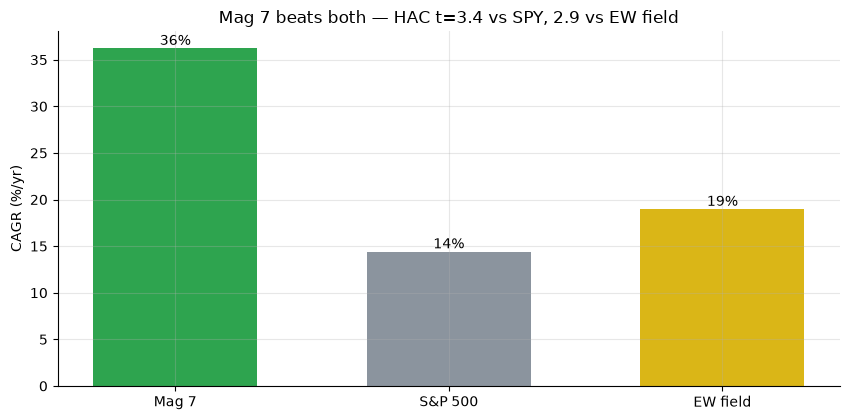

Mag 7 - SPY      : +19.9%/yr  HAC t=3.41
Mag 7 - EW field : +15.8%/yr  HAC t=2.88


In [2]:
if HAVE_REAL:
    mag7 = st.basket_returns(RETS, data.MAG7); eqf = st.equal_field_returns(RETS)
    legs = {'Mag 7': st.summarize(mag7)['cagr'], 'S&P 500': st.summarize(BENCH)['cagr'],
            'EW field': st.summarize(eqf)['cagr']}
    tb = st.hac_tstat_diff(mag7, BENCH); te = st.hac_tstat_diff(mag7, eqf)
    legs = {k: v*100 for k,v in legs.items()}
else:
    legs = {'Mag 7': R['mag7_cagr'], 'S&P 500': R['spy_cagr'], 'EW field': R['eqf_cagr']}
    tb = {'tstat': R['t_bench'], 'mean_diff_ann': R['spread_bench_ann']/100}
    te = {'tstat': R['t_equal'], 'mean_diff_ann': R['spread_equal_ann']/100}
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(list(legs), list(legs.values()), color=[GREEN, GREY, AMBER], width=.6)
for i,v in enumerate(legs.values()): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('CAGR (%/yr)'); ax.set_title(f"Mag 7 beats both — HAC t={tb['tstat']:.1f} vs SPY, {te['tstat']:.1f} vs EW field")
plt.tight_layout(); plt.show()
print(f"Mag 7 - SPY      : {tb['mean_diff_ann']*100:+.1f}%/yr  HAC t={tb['tstat']:.2f}")
print(f"Mag 7 - EW field : {te['mean_diff_ann']*100:+.1f}%/yr  HAC t={te['tstat']:.2f}")

> 💡 In plain words: the spread is **real on the tape** — +20%/yr at **t = 3.4** vs the index, and still **t = 2.9** after stripping the equal-weight tilt (so it is *name* selection, not just a weighting trick). H₁ accepted. That's the half the pitch gets right — and the half that doesn't help you.

### 4b · …but it is selection — the Mag 7 vs the blind-pick distribution

The CAGR spread over SPY of 2,000 seeded random 7-baskets (the forward, no-skill law) with the famous seven, and the ex-post "pick the winners" basket, marked.

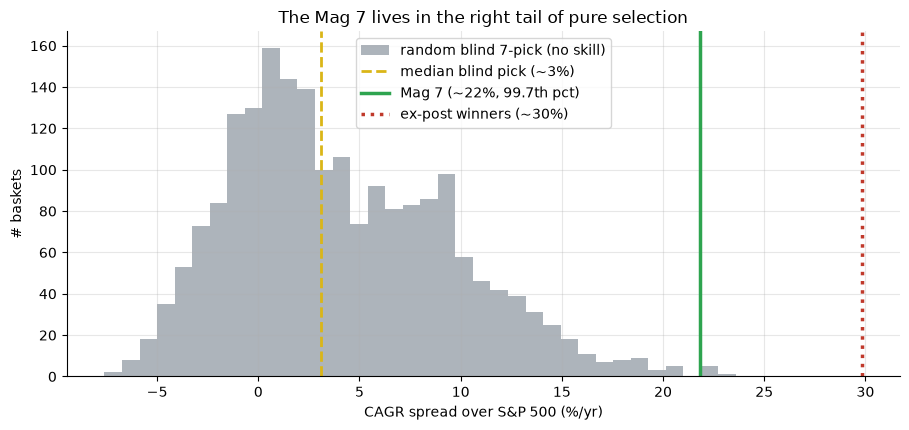

blind median +3.1%  |  Mag 7 +21.8% (99.7th pct)  |  ex-post winners +29.8%


In [3]:
if HAVE_REAL:
    rands = st.random_baskets(RETS, k=7, n_draws=2000, seed=355)
    spy = st.summarize(BENCH)['cagr']
    rs = (np.array([st.summarize(rands[c])['cagr'] for c in rands.columns]) - spy)*100
    mag_sp = (st.summarize(st.basket_returns(RETS, data.MAG7))['cagr'] - spy)*100
    win = st.expost_winners(RETS, k=7, allow_lookahead_selection=True)
    exp_sp = (st.summarize(st.basket_returns(RETS, win))['cagr'] - spy)*100
    pct = st.percentile_of(mag_sp, rs)
else:
    rng = np.random.default_rng(355); rs = rng.normal(R['rand_mean'], 6.0, 2000)
    mag_sp, exp_sp, pct = R['mag7_spread'], R['expost_spread'], R['mag7_pctile']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(rs, bins=36, color=GREY, alpha=.7, label='random blind 7-pick (no skill)')
ax.axvline(np.median(rs), c=AMBER, lw=2, ls='--', label=f'median blind pick (~{np.median(rs):.0f}%)')
ax.axvline(mag_sp, c=GREEN, lw=2.5, label=f'Mag 7 (~{mag_sp:.0f}%, {pct:.1f}th pct)')
ax.axvline(exp_sp, c=RED, lw=2.5, ls=':', label=f'ex-post winners (~{exp_sp:.0f}%)')
ax.set_xlabel('CAGR spread over S&P 500 (%/yr)'); ax.set_ylabel('# baskets')
ax.set_title('The Mag 7 lives in the right tail of pure selection'); ax.legend()
plt.tight_layout(); plt.show()
print(f'blind median {np.median(rs):+.1f}%  |  Mag 7 {mag_sp:+.1f}% ({pct:.1f}th pct)  |  ex-post winners {exp_sp:+.1f}%')

> 💡 In plain words: a *blindly* chosen seven beat SPY by a median **~3%/yr**; the Mag 7 by **~22%**, sitting at the **99.7th** percentile — and the explicit "pick the winners" rule reaches **~30%**, reproducing **137%** of the Mag-7 spread. The famous seven are ~6 of the 7 ex-post winners (the 7th is **AMD**, not META). H₂ rejected: the spread is *where you'd be if you'd picked the winners*, not where a forward pick lands.

### 4c · The placebo on a no-edge tape — selection from nothing

The clinching control. On a deterministic synthetic panel where the *pre-named* basket carries `alpha_spread` and everyone else is identical, compare the **pre-named** spread (the honest factor, with its *t*) to the **ex-post placebo** spread (selection).

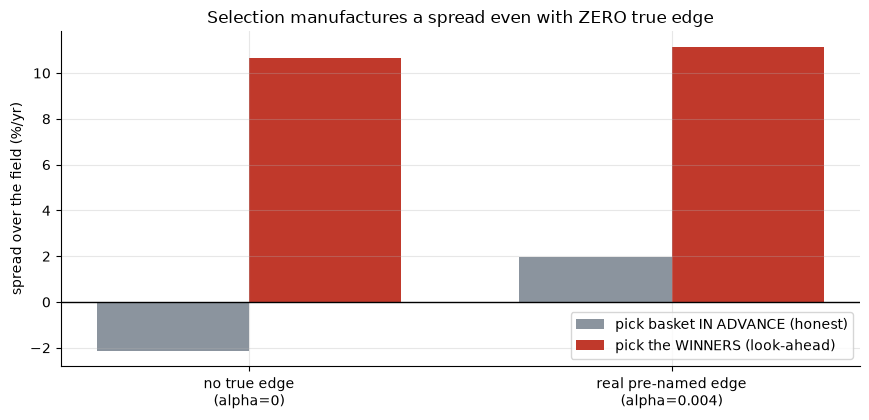

alpha=0.000: pre-named -2.1%/yr (t=-1.15)   ex-post placebo +10.7%/yr
alpha=0.004: pre-named +2.0%/yr (t=+1.20)   ex-post placebo +11.2%/yr


In [4]:
rows = []
for a in (0.0, 0.004):
    rdf, b, truth = data.synthetic_panel(alpha_spread=a)
    named = st.basket_returns(rdf, truth['true_basket_cols'])
    expo  = st.basket_returns(rdf, st.expost_winners(rdf, k=7, allow_lookahead_selection=True))
    sb = st.summarize(b)['cagr']
    rows.append((a, (st.summarize(named)['cagr']-sb)*100, st.hac_tstat_diff(named,b)['tstat'],
                    (st.summarize(expo)['cagr']-sb)*100))
labels = ['no true edge\n(alpha=0)', 'real pre-named edge\n(alpha=0.004)']
named_sp = [r[1] for r in rows]; placebo_sp = [r[3] for r in rows]
x=np.arange(2); fig,ax=plt.subplots(figsize=(8.8,4.3))
ax.bar(x-.18, named_sp, .36, color=GREY, label='pick basket IN ADVANCE (honest)')
ax.bar(x+.18, placebo_sp, .36, color=RED, label='pick the WINNERS (look-ahead)')
ax.axhline(0,c='k',lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('spread over the field (%/yr)'); ax.set_title('Selection manufactures a spread even with ZERO true edge'); ax.legend()
plt.tight_layout(); plt.show()
for a,n,t,e in rows: print(f'alpha={a:.3f}: pre-named {n:+.1f}%/yr (t={t:+.2f})   ex-post placebo {e:+.1f}%/yr')

> 💡 In plain words: the null row (`alpha=0`) is decisive. With **no** true cross-sectional edge, a basket fixed *in advance* shows **-2%/yr** (t = -1.15 — luck) while the look-ahead rule conjures **+11%/yr** from nothing. The engine is faithful: it finds a spread *only* where one is planted (pre-named) and manufactures one *whenever* you select on the outcome. That manufactured spread is the artefact the Mag-7 label carries by construction.

## 5 · The verdict

- **Signal `MIXED`** — the realised spread is genuine (+19.9%/yr, HAC **t = 3.41**, n = 130; t = 2.88 vs the EW field), so it is *not* a pure weighting artefact. But the basket is **selected on the outcome**: the no-edge null still yields a +11%/yr placebo, the ex-post rule reproduces 137% of the spread, and the seven sit at the 99.7th percentile of random baskets. Real recent spread, look-ahead/survivorship selected → `MIXED` (a `WEAK` forward case under a strong in-sample t).
- **Tradability `MIRAGE`** — costs are immaterial (net CAGR 36.1% ≈ gross 36.2%). The mirage is that the basket was unknowable ex ante; the forward-tradable object is the random seven (~+4%/yr, −46% drawdown) or a pre-named factor (which the null shows can be zero).
- **Repeatable strategy? `BUSTED`** — "hold the realised winners" is a label, not a forward rule; out-of-selection it is the random distribution (median +3%/yr), not +22%. The Mag 7 is yesterday's winners.

## 6 · Could you trade it? — the forward vs hindsight gap

The single number that settles tradability: the CAGR spread you'd have captured **forward** (a blind seven) versus the spread hindsight *names* (the Mag 7, the ex-post winners). The gap is the selection premium — unbuyable in real time.

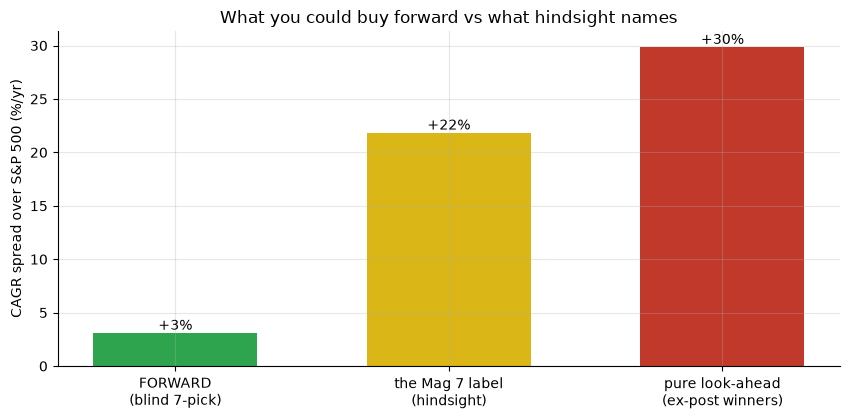

forward (blind median) +3%  ->  Mag 7 label +22%  ->  pure look-ahead +30%


In [5]:
if HAVE_REAL:
    spy = st.summarize(BENCH)['cagr']
    rands = st.random_baskets(RETS, k=7, n_draws=2000, seed=355)
    blind = float(np.median([st.summarize(rands[c])['cagr'] for c in rands.columns]) - spy)*100
    mag_sp = (st.summarize(st.basket_returns(RETS, data.MAG7))['cagr'] - spy)*100
    exp_sp = (st.summarize(st.basket_returns(RETS, st.expost_winners(RETS,7,allow_lookahead_selection=True)))['cagr'] - spy)*100
else:
    blind, mag_sp, exp_sp = R['rand_median'], R['mag7_spread'], R['expost_spread']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ['FORWARD\n(blind 7-pick)', 'the Mag 7 label\n(hindsight)', 'pure look-ahead\n(ex-post winners)']
vals = [blind, mag_sp, exp_sp]
ax.bar(bars, vals, color=[GREEN, AMBER, RED], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('CAGR spread over S&P 500 (%/yr)'); ax.set_title('What you could buy forward vs what hindsight names')
plt.tight_layout(); plt.show()
print(f'forward (blind median) {blind:+.0f}%  ->  Mag 7 label {mag_sp:+.0f}%  ->  pure look-ahead {exp_sp:+.0f}%')

> 💡 In plain words: the buyable, forward edge is ~**+3%/yr** (a blind seven). Everything above that — up to the **+22%** the Mag-7 label shows and the **+30%** of pure hindsight — is the **selection premium**, available only to someone who already knows the answer. There is no sizing, no rebalance, no cost assumption that converts the hindsight bars into a forward one.

## 7 · Going further

- **The panel-level twin.** [Study 345 — Survivorship-Bias](../../345-survivorship-bias/): delete the *losers* before the backtest sees them — the Mag 7 keeps only the seven top *winners*, the mirror image.
- **The honest forward benchmark.** [Study 350 — Dartboard-Portfolio](../../350-dartboard-portfolio/) supplies the random-basket distribution and the equal-vs-cap decomposition reused here.
- **Point-in-time membership.** The cleanest extension: rank names by trailing momentum *at each date* and hold the top 7 going forward (no look-ahead). The prior is that this earns the decayed, regime-dependent momentum premium — far below the +22% the static label shows. ~Survivorship: add the mega-caps that *died* (e.g. GE's collapse) to the field and the blind-pick spread falls further.

*The reproducible core is offline and deterministic; the look-ahead rule is gated behind an explicit opt-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*